# Wearable Activity and Heart Rate Analysis

Exploratory analysis of wearable physiological signals using the **MMASH dataset**.

Goal:
- explore relationships between **activity, heart rate, and sleep**
- detect **activity vs inactivity**
- investigate **multi-day physiological patterns**

Dataset:
https://physionet.org/content/mmash/1.0.0/

Signals used:
- triaxial accelerometer
- heart rate (RR intervals)
- sleep annotations

In [9]:
""" 1. A) Import """ 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import os

sns.set(style="whitegrid")

""" 1. B) Define Constants """
DATA_PATH_USER1 = DATA_PATH = "../data/physionet.org/files/mmash/1.0.0/DataPaper/user_1/"

In [14]:
""" 2. Load Data """ 
# os.listdir("../data/physionet.org/files/mmash/1.0.0/DataPaper/")
activity = pd.read_csv(DATA_PATH + "Activity.csv")
rr = pd.read_csv(DATA_PATH + "RR.csv")
sleep = pd.read_csv(DATA_PATH + "sleep.csv")

In [16]:
print(activity.head())
print(rr.head())
print(sleep.head())
print("Columns activity: ", activity.columns)
print("Columns RR: ", rr.columns)
print("Columns sleep: ", sleep.columns)
print("Activity shape: ", activity.shape)
print("RR shape: ", rr.shape)
print("Sleep shape: ", sleep.shape)

   Unnamed: 0  Activity  Start    End  Day
0           0         2  10:00  10:22    1
1           1         9  10:37  10:40    1
2           2        10  10:40  10:45    1
3           3         6  10:55  11:00    1
4           4         2  11:00  11:20    1
   Unnamed: 0  ibi_s  day      time
0           1  0.258    1  10:10:17
1           2  0.319    1  10:10:18
2           3  0.266    1  10:10:18
3           4  0.401    1  10:10:18
4           5  1.089    1  10:10:19
   Unnamed: 0  In Bed Date In Bed Time  Out Bed Date Out Bed Time  Onset Date  \
0           0            2       00:46             2        03:31           2   
1           1            2       03:57             2        07:30           2   

  Onset Time  Latency  Efficiency  Total Minutes in Bed  \
0      00:46        0       87.27                   165   
1      03:57        0       92.02                   213   

   Total Sleep Time (TST)  Wake After Sleep Onset (WASO)  \
0                     144                   

In [ ]:
print(activity["Activity"].unique())
print(activity["Activity"].value_counts())

[ 2  9 10  6  7  4  3  5  8  1  0]
Activity
10    9
3     5
2     4
6     4
9     3
4     2
7     1
5     1
8     1
1     1
0     1
Name: count, dtype: int64


In [22]:
activity_map = {
1: "sleeping",
2: "laying",
3: "sitting",
4: "light_activity",
5: "moderate_activity",
6: "vigorous_activity",
7: "eating",
8: "small_screen",
9: "large_screen",
10: "caffeine",
11: "smoking",
12: "alcohol"
}

activity["activity_label"] = activity["Activity"].map(activity_map)

In [23]:
activity[["Activity","activity_label"]].head()

,Activity,activity_label
0,2,laying
1,9,large_screen
2,10,caffeine
3,6,vigorous_activity
4,2,laying


In [25]:
activity["Start"] = pd.to_datetime(activity["Start"], format="%H:%M")
activity["End"] = pd.to_datetime(activity["End"], format="%H:%M")

In [26]:
activity["duration_min"] = (activity["End"] - activity["Start"]).dt.total_seconds() / 60

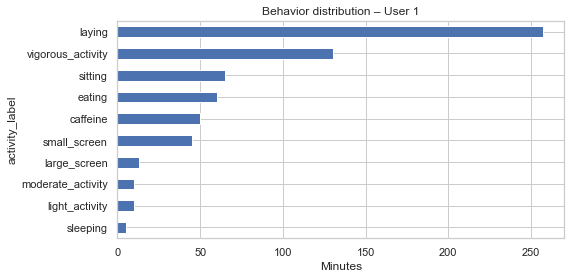

In [28]:
activity.groupby("activity_label")["duration_min"].sum().sort_values().plot.barh(figsize=(8,4))
plt.title("Behavior distribution – User 1")
plt.xlabel("Minutes")
plt.show()